## Task 1: Agent Concepts & Mental Model

### Agent vs. Chatbot vs. Workflow

* **Chatbot:** A conversational system that generates responses turn-by-turn based on the conversation context. A basic chatbot does not autonomously take actions or use external tools.

* **Workflow:** A deterministic control pipeline. Steps and execution branches are hardcoded by the software engineer (e.g., fetch API -> transform data -> call LLM).

* **Agent:** An LLM inside a control loop acting as the decision engine. It plans steps, selects tools, inspects outputs, and iterates autonomously until a task is resolved.

### What Makes a System Agentic?

Agentic behavior combines **autonomy, tool use, multi-step planning, observation, and self-correction**. The agent can inspect the result of an action, detect when the result is insufficient or incorrect, and choose a different or additional action instead of blindly following a fixed sequence.

### ReAct Loop

**Reason (Decision)** -> **Act (Action / Tool Call)** -> **Observe (Observation / Function Response)** -> **Reason again** -> Repeat until a final plain-text answer is produced.

```text
User Request
     ↓
   REASON
     ↓
     ACT
 (Tool Call)
     ↓
  OBSERVE
(Tool Result)
     ↓
   REASON
     ↓
Repeat if needed
     ↓
Final Answer

In [8]:
%pip install -q -U google-genai

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
%load_ext autoreload
%autoreload 2

import os
import sys
import json
from pathlib import Path
from dotenv import load_dotenv

# Ensure the notebook loads from the correct directory
HERE = Path.cwd() if (Path.cwd() / "tools.py").is_file() else Path.cwd() / "week 2" / "day 1"
load_dotenv(HERE / ".env", override=True)
sys.path.insert(0, str(HERE))

from agent import default_model, make_client, user_api_key
from tools import TOOL_FNS, TOOL_SCHEMAS

# Verify API key and client connectivity
key = user_api_key() or os.getenv("GEMINI_API_KEY")
if not key:
    raise RuntimeError(f"Missing GEMINI_API_KEY in {HERE / '.env'}")

client = make_client()
model_name = default_model()
print(f"Environment ready | Model: {model_name} | Key: ...{key[-4:]}")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Environment ready | Model: gemini-3.5-flash-lite | Key: ...p2dA


LIVE Gemini ready | model: gemini-3.5-flash-lite | key …p2dA


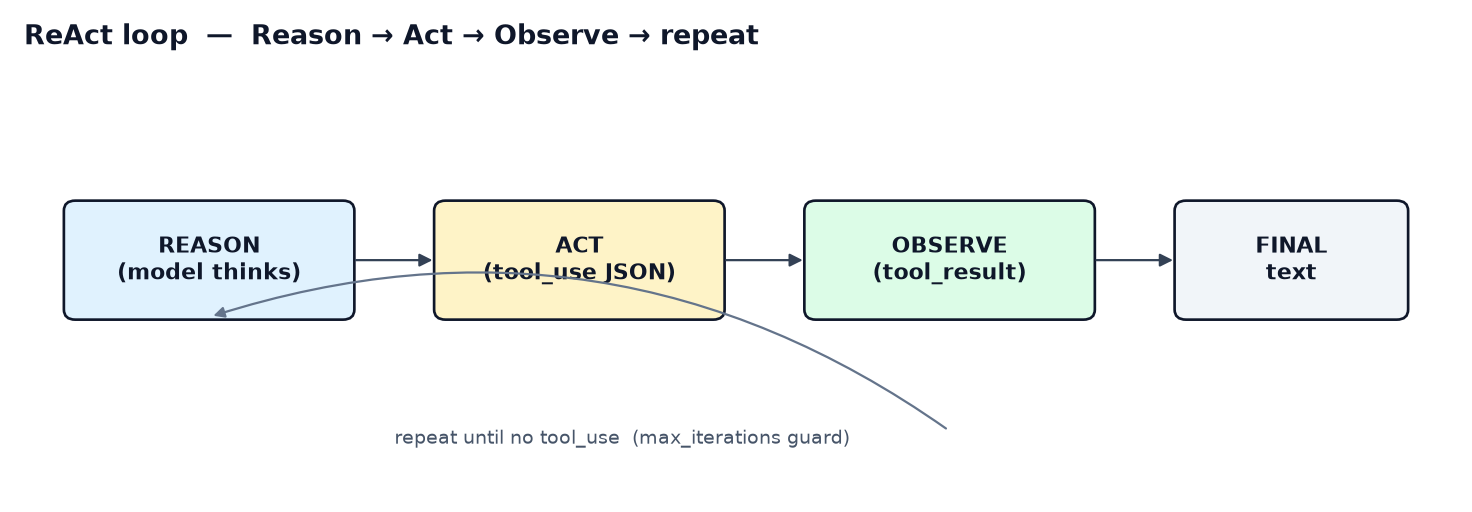

In [10]:
from IPython.display import Image, display

# Display ReAct diagram
img = HERE / "react_loop.png"
if img.is_file():
    display(Image(filename=str(img)))
else:
    print(f"ReAct diagram not found: {img}")


## Task 2: Tool Calling Fundamentals

### Core Concept: Why Tool Descriptions Matter
Language models do not read your Python code or understand its internal logic. At runtime, the model only sees the JSON Schema exposed to it: the tool's `name`, `description`, and parameter properties.

The description serves as the model's semantic routing instruction:
* **Tool Selection:** Clear, precise descriptions establish explicit boundaries for what a tool can and cannot do, preventing the model from picking the wrong tool or guessing.
* **Argument Formatting:** Explicit property descriptions (e.g., `"City name, e.g. 'Karachi' or 'London'"`) instruct the model on the exact format to pass, preventing extraneous natural language, punctuation, or missing parameters.
* **Grounding vs. Hallucination:** Ambiguous or missing descriptions cause the model to lose confidence in calling a tool, often falling back to fabricating answers from internal weights instead of fetching ground truth.

---

### Defined Tools & Schema Design

Our local sandbox defines deterministic tools mapped to standard schemas:

1. **`calculator`**: Safely parses and evaluates basic arithmetic via an AST parser (`+ - * / // % **`), blocking dangerous arbitrary code execution.
2. **`get_weather`**: Deterministic city lookup stub returning Celsius temperature and conditions for supported cities (`Karachi`, `London`, `Tokyo`, `New York`, `Oslo`).
3. **`read_sandbox_file`**: Reads local sandbox files while strictly enforcing sandbox path isolation to prevent directory traversal attacks (`../../`).
4. **`broken_lookup`**: Deliberately raises an unhandled runtime error for resilience testing.

---

### Manual Round-Trip Mechanics

The tool execution lifecycle consists of three distinct phases:

1. **Model Invocation (Selection):** We send the user query alongside function declarations. The model responds with a `function_call` block rather than plain text.
2. **Local Execution (Host Environment):** The Python runtime extracts the requested function name and arguments, executes the corresponding local function, and captures the output.
3. **Observation Feedback (Grounding):** We package the output into a `function_response` block and return it to the model, which reads the observation and generates the final, grounded response.

In [17]:
from google.genai import types

print("=" * 80)
print("TASK 2: TOOL CALLING FUNDAMENTALS")
print("=" * 80)

print("\n--- Local Sanity Checks ---")
print("calculator('33 - 12') ->", TOOL_FNS["calculator"]("33 - 12"))
print("get_weather('Karachi') ->", TOOL_FNS["get_weather"]("Karachi"))
print("read_sandbox_file('briefing.txt') ->", TOOL_FNS["read_sandbox_file"]("briefing.txt"))

print("\n--- Tool Schemas ---")

for schema in TOOL_SCHEMAS:
    print(f"\nTool: {schema['name']}")
    print(f"Description: {schema['description']}")
    print(f"Input Schema: {schema['input_schema']}")

tool_declarations = [
    types.FunctionDeclaration(
        name=schema["name"],
        description=schema["description"],
        parameters=schema["input_schema"],
    )
    for schema in TOOL_SCHEMAS
]

config = types.GenerateContentConfig(
    tools=[
        types.Tool(
            function_declarations=tool_declarations
        )
    ]
)

prompt = "What is 21 * 4? Use the calculator tool."

contents = [
    types.Content(
        role="user",
        parts=[
            types.Part(text=prompt)
        ]
    )
]

print("\n--- User Request ---")
print(prompt)

response_1 = client.models.generate_content(
    model=model_name,
    contents=contents,
    config=config
)

model_content = response_1.candidates[0].content

function_calls = [
    part.function_call
    for part in model_content.parts
    if part.function_call is not None
]

if not function_calls:
    raise RuntimeError("Gemini did not select a function.")

print("\n--- Model Selected Tool ---")

function_response_parts = []

for call in function_calls:
    tool_name = call.name
    tool_args = dict(call.args or {})

    print(f"Tool: {tool_name}")
    print(f"Arguments: {tool_args}")

    if tool_name not in TOOL_FNS:
        result = {
            "error": f"Unknown tool: {tool_name}"
        }
    else:
        try:
            result = TOOL_FNS[tool_name](**tool_args)
        except Exception as exc:
            result = {
                "error": str(exc)
            }

    print(f"\n--- Local Tool Execution ---")
    print(f"Tool: {tool_name}")
    print(f"Output: {result}")

    function_response_parts.append(
        types.Part.from_function_response(
            name=tool_name,
            response={
                "result": result
            }
        )
    )

contents.append(model_content)

contents.append(
    types.Content(
        role="user",
        parts=function_response_parts
    )
)

print("\n--- Function Response Returned to Gemini ---")

for part in function_response_parts:
    print(part.function_response)

response_2 = client.models.generate_content(
    model=model_name,
    contents=contents,
    config=config
)

print("\n--- Final Model Response ---")
print(response_2.text.strip())

TASK 2: TOOL CALLING FUNDAMENTALS

--- Local Sanity Checks ---
calculator('33 - 12') -> 21
get_weather('Karachi') -> Karachi: 33 C, hot, humid
read_sandbox_file('briefing.txt') -> Karachi briefing
- Coastal megacity, typical summer afternoon ~33 C in this stub.
- Compare against London when asked which city is warmer.

London briefing
- Cool maritime climate in this stub (~12 C).


--- Tool Schemas ---

Tool: calculator
Description: Evaluate a basic arithmetic expression and return the numeric result as text. Use for comparisons that need subtraction or conversion (for example C to F). Allowed operators: + - * / // % **. Do not send words or units, only the expression.
Input Schema: {'type': 'object', 'properties': {'expression': {'type': 'string', 'description': "Arithmetic expression such as '33 - 12' or '(9/5)*33 + 32'."}}, 'required': ['expression']}

Tool: get_weather
Description: Look up current weather for one city from a local stub database. Call once per city. Supported cities

# Task 3 — Minimal agent loop

`run_agent` in `agent.py`:

1. Send the user message.
2. If the response has `tool_use`, execute the tool and append `tool_result`.
3. Repeat until the model returns a final text answer.
4. Stop anyway at `max_iterations=8` (safeguard).

The next cell is a **multi-step** live task: weather in two cities, which is warmer (2+ tool calls).


In [18]:
from agent import run_agent

question = (
    "Look up the weather in Karachi and in London. "
    "Which city is warmer, and by how many degrees Celsius? "
    "Use tools; do not guess temperatures."
)
result = run_agent(question, max_iterations=8, verbose=True)
print("\nstopped:", result["stopped"], "| tool calls:", sum(1 for r in result["transcript"] if r["kind"] == "act"))
print("\n=== FINAL ===\n", result["final_text"])


[user       ] Look up the weather in Karachi and in London. Which city is warmer, and by how many degrees Celsius? Use tools; do not guess temperatures.
[reason     ] iteration 1/8 — calling Gemini
[act        ] get_weather  input={"city": "Karachi"}
[observe    ] Karachi: 33 C, hot, humid
[act        ] get_weather  input={"city": "London"}
[observe    ] London: 12 C, overcast, light rain
[reason     ] iteration 2/8 — calling Gemini
[act        ] calculator  input={"expression": "33 - 12"}
[observe    ] 21
[reason     ] iteration 3/8 — calling Gemini
[thought    ] Karachi is warmer than London. Karachi is currently 33°C, while London is 12°C. Karachi is warmer by 21 degrees Celsius.
[final      ] Karachi is warmer than London. Karachi is currently 33°C, while London is 12°C. Karachi is warmer by 21 degrees Celsius.

stopped: completed | tool calls: 3

=== FINAL ===
 Karachi is warmer than London. Karachi is currently 33°C, while London is 12°C. Karachi is warmer by 21 degrees Celsius.


# Task 4 — Memory & state

**Conversation memory** = the `messages` list sent to the API (user / assistant / tool_result). Drop a turn and the model forgets it.

**Working memory** = state *you* keep mid-task: the transcript log, iteration counter, `stopped` flag. That scratchpad is not inside the LLM unless you write it into `messages`.

The `[reason] [thought] [act] [observe] [final]` prints are the debugging habit for every framework later.

The next cell prints both memories from the Task 3 run.


In [13]:
print("Conversation memory — API turns:", len(result["messages"]))
for i, m in enumerate(result["messages"]):
    content = m["content"]
    if isinstance(content, str):
        preview = content[:90]
    else:
        kinds = []
        for b in content:
            kinds.append(b.get("type", "?") if isinstance(b, dict) else getattr(b, "type", type(b).__name__))
        preview = ",".join(kinds)
    print(f"  [{i}] {m['role']:10} {preview}")

print("\nWorking memory — scratchpad:")
for row in result["transcript"]:
    print(f"  {row['kind']:11} {row['text'][:110]}")


Conversation memory — API turns: 6
  [0] user       Look up the weather in Karachi and in London. Which city is warmer, and by how many degree
  [1] assistant  function_call,function_call
  [2] user       function_response,function_response
  [3] assistant  function_call
  [4] user       function_response
  [5] assistant  Karachi is warmer than London. Karachi is currently 33°C, while London is 12°C. Karachi is

Working memory — scratchpad:
  user        Look up the weather in Karachi and in London. Which city is warmer, and by how many degrees Celsius? Use tools
  reason      iteration 1/8 — calling Gemini
  act         get_weather  input={"city": "Karachi"}
  observe     Karachi: 33 C, hot, humid
  act         get_weather  input={"city": "London"}
  observe     London: 12 C, overcast, light rain
  reason      iteration 2/8 — calling Gemini
  act         calculator  input={"expression": "33 - 12"}
  observe     21
  reason      iteration 3/8 — calling Gemini
  thought     Karachi is w

# Task 5 — Failure modes & guardrails

The next cell **deliberately breaks** the live agent: an ambiguous request, a tool that errors, and a task that needs a tool we did not define.

| Failure | Mitigation |
|---|---|
| Infinite Reason–Act loop | `max_iterations` hard stop |
| Hallucinated tool name | Unknown-name `ERROR` + `is_error=True` |
| Wrong / unsafe arguments | JSON `input_schema`; calculator uses AST, not `eval` |
| Silent exceptions | `try/except` → log `[observe]` as `ERROR:…` |
| Ambiguous request | Ask a clarifying question; do not guess a city |
| Missing tool (stock price) | Refuse to invent a quote |

**Why LangChain / LangGraph / CrewAI exist:** we just built schemas, a client call, a while-loop, logs, and a stop condition. That is enough to *understand* an agent. Frameworks add retries, tracing, graphs, human-in-the-loop, and memory so you do not rewrite this file for every project. They wrap ReAct. They are not a different kind of intelligence.


In [14]:
from agent import run_agent

print("=" * 72)
print("BREAK 1 — ambiguous request")
print("=" * 72)
run_agent("Please just do the thing.", max_iterations=4, verbose=True)

print("\n" + "=" * 72)
print("BREAK 2 — tool that returns an error")
print("=" * 72)
run_agent("Call broken_lookup with query 'secret-db' and tell me the result.", max_iterations=4, verbose=True)

print("\n" + "=" * 72)
print("BREAK 3 — task needs a tool we did not define")
print("=" * 72)
run_agent("What is the live stock price of ticker XQZZ? Use tools.", max_iterations=4, verbose=True)


BREAK 1 — ambiguous request
[user       ] Please just do the thing.
[reason     ] iteration 1/4 — calling Gemini
[thought    ] Please let me know what "the thing" is—whether you'd like me to check the weather in a specific city, read a file from the sandbox, or something else!
[final      ] Please let me know what "the thing" is—whether you'd like me to check the weather in a specific city, read a file from the sandbox, or something else!

BREAK 2 — tool that returns an error
[user       ] Call broken_lookup with query 'secret-db' and tell me the result.
[reason     ] iteration 1/4 — calling Gemini
[act        ] broken_lookup  input={"query": "secret-db"}
[observe    ] ERROR: RuntimeError: upstream timeout while looking up 'secret-db'
[reason     ] iteration 2/4 — calling Gemini
[thought    ] The tool call to `broken_lookup` failed with the following error:

`ERROR: RuntimeError: upstream timeout while looking up 'secret-db'`
[final      ] The tool call to `broken_lookup` failed with t

{'final_text': 'I do not have a tool available to fetch live stock prices or look up the ticker XQZZ.',
 'transcript': [{'kind': 'user',
   'text': 'What is the live stock price of ticker XQZZ? Use tools.'},
  {'kind': 'reason', 'text': 'iteration 1/4 — calling Gemini'},
  {'kind': 'thought',
   'text': 'I do not have a tool available to fetch live stock prices or look up the ticker XQZZ.'},
  {'kind': 'final',
   'text': 'I do not have a tool available to fetch live stock prices or look up the ticker XQZZ.'}],
 'messages': [{'role': 'user',
   'content': 'What is the live stock price of ticker XQZZ? Use tools.'},
  {'role': 'assistant',
   'content': 'I do not have a tool available to fetch live stock prices or look up the ticker XQZZ.'}],
 'stopped': 'completed',
 'model': 'gemini-3.5-flash-lite'}